Download employee retention dataset from here: https://www.kaggle.com/giripujar/hr-analytics. 
1. Now do some exploratory data analysis to figure out which variables have direct and clear impact on employee retention (i.e. whether they leave the company or continue to work)
2. Plot bar charts showing impact of employee salaries on retention
3. Plot bar charts showing corelation between department and employee retention
4. Now build logistic regression model using variables that were narrowed down in step 1
5. Measure the accuracy of the model

In [52]:
import pandas as pd
import numpy as np

df = pd.read_csv('HR_comma_sep.csv')
df1 = df
df.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


In [53]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   Department             14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


In [54]:
df.describe()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


In [55]:
df.isnull().sum()

satisfaction_level       0
last_evaluation          0
number_project           0
average_montly_hours     0
time_spend_company       0
Work_accident            0
left                     0
promotion_last_5years    0
Department               0
salary                   0
dtype: int64

In [56]:
df['Department'].unique()

array(['sales', 'accounting', 'hr', 'technical', 'support', 'management',
       'IT', 'product_mng', 'marketing', 'RandD'], dtype=object)

In [57]:
df = pd.get_dummies(df,columns=['Department'],dtype=int)
df.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,salary,Department_IT,Department_RandD,Department_accounting,Department_hr,Department_management,Department_marketing,Department_product_mng,Department_sales,Department_support,Department_technical
0,0.38,0.53,2,157,3,0,1,0,low,0,0,0,0,0,0,0,1,0,0
1,0.80,0.86,5,262,6,0,1,0,medium,0,0,0,0,0,0,0,1,0,0
2,0.11,0.88,7,272,4,0,1,0,medium,0,0,0,0,0,0,0,1,0,0
3,0.72,0.87,5,223,5,0,1,0,low,0,0,0,0,0,0,0,1,0,0
4,0.37,0.52,2,159,3,0,1,0,low,0,0,0,0,0,0,0,1,0,0


In [58]:
from sklearn.preprocessing import OrdinalEncoder
cat = [['low','medium','high']]
encoder = OrdinalEncoder(categories=cat)
df['salary']=encoder.fit_transform(df[['salary']])

mapping = dict(zip(encoder.categories_[0],range(len(encoder.categories[0]))))
print(mapping)


{'low': 0, 'medium': 1, 'high': 2}


In [59]:
df.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,salary,Department_IT,Department_RandD,Department_accounting,Department_hr,Department_management,Department_marketing,Department_product_mng,Department_sales,Department_support,Department_technical
0,0.38,0.53,2,157,3,0,1,0,0.0,0,0,0,0,0,0,0,1,0,0
1,0.80,0.86,5,262,6,0,1,0,1.0,0,0,0,0,0,0,0,1,0,0
2,0.11,0.88,7,272,4,0,1,0,1.0,0,0,0,0,0,0,0,1,0,0
3,0.72,0.87,5,223,5,0,1,0,0.0,0,0,0,0,0,0,0,1,0,0
4,0.37,0.52,2,159,3,0,1,0,0.0,0,0,0,0,0,0,0,1,0,0


In [60]:
df.corr()['left']

satisfaction_level       -0.388375
last_evaluation           0.006567
number_project            0.023787
average_montly_hours      0.071287
time_spend_company        0.144822
Work_accident            -0.154622
left                      1.000000
promotion_last_5years    -0.061788
salary                   -0.157898
Department_IT            -0.010925
Department_RandD         -0.046596
Department_accounting     0.015201
Department_hr             0.028249
Department_management    -0.046035
Department_marketing     -0.000859
Department_product_mng   -0.011029
Department_sales          0.009923
Department_support        0.010700
Department_technical      0.020076
Name: left, dtype: float64

<Axes: >

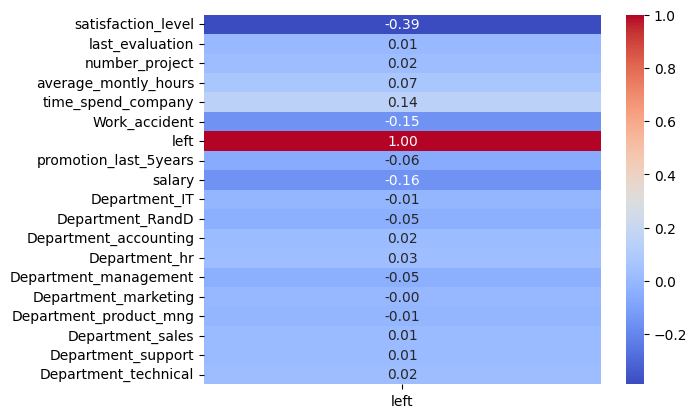

In [61]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.heatmap(df.corr()[['left']],annot=True,cmap = 'coolwarm',fmt = '.2f')

therefore satisfaction level varianle has the direct and clear impact on employee retention (i.e. whether they leave the company or continue to work)

In [62]:
df.satisfaction_level.unique()

array([0.38, 0.8 , 0.11, 0.72, 0.37, 0.41, 0.1 , 0.92, 0.89, 0.42, 0.45,
       0.84, 0.36, 0.78, 0.76, 0.09, 0.46, 0.4 , 0.82, 0.87, 0.57, 0.43,
       0.13, 0.44, 0.39, 0.85, 0.81, 0.9 , 0.74, 0.79, 0.17, 0.24, 0.91,
       0.71, 0.86, 0.14, 0.75, 0.7 , 0.31, 0.73, 0.83, 0.32, 0.54, 0.27,
       0.77, 0.88, 0.48, 0.19, 0.6 , 0.12, 0.61, 0.33, 0.56, 0.47, 0.28,
       0.55, 0.53, 0.59, 0.66, 0.25, 0.34, 0.58, 0.51, 0.35, 0.64, 0.5 ,
       0.23, 0.15, 0.49, 0.3 , 0.63, 0.21, 0.62, 0.29, 0.2 , 0.16, 0.65,
       0.68, 0.67, 0.22, 0.26, 0.99, 0.98, 1.  , 0.52, 0.93, 0.97, 0.69,
       0.94, 0.96, 0.18, 0.95])

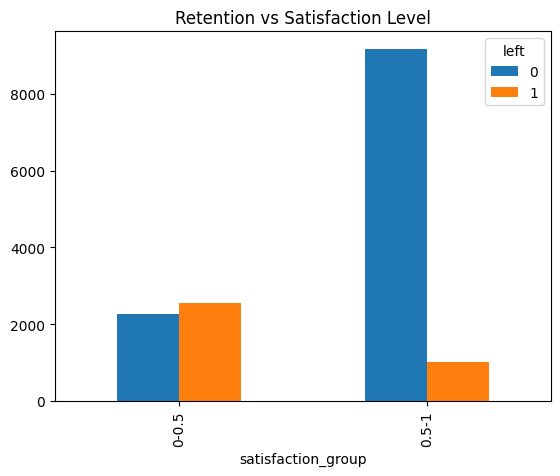

In [114]:
bins = [0, 0.5, 1]
labels = ['0-0.5', '0.5-1']

df['satisfaction_group'] = pd.cut(df['satisfaction_level'], bins=bins, labels=labels)


pd.crosstab(df['satisfaction_group'], df['left']).plot(kind='bar')
plt.title("Retention vs Satisfaction Level")
plt.show()

THIS SHOWS THE EMPLOYEE WHO HAS MORE SATISFACTION LEVEL THEY WILL MORE LIKELY TO LEFT THE COMPANY

bar charts showing impact of employee salaries on retention


<Axes: xlabel='salary', ylabel='left'>

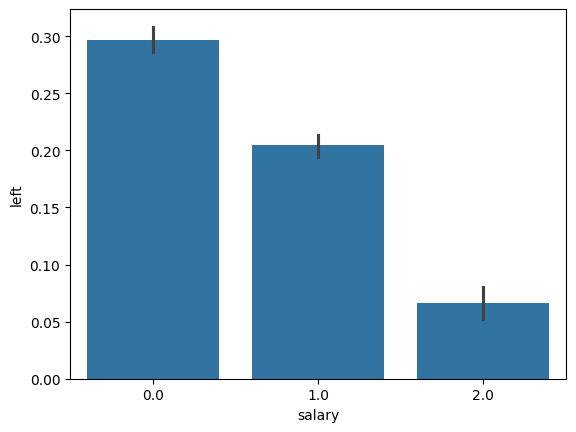

In [63]:
sns.barplot(df,x='salary',y='left')

This shows that the employee who get more salary are less likely to left the job

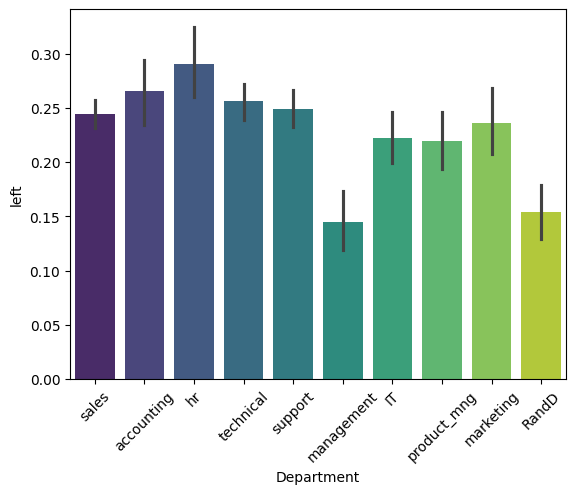

In [69]:
sns.barplot(df1,x='Department',y='left',hue='Department',palette='viridis')
plt.xticks(rotation=45)
plt.show()

this showing corelation between department and employee retention

In [82]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

x = df[['satisfaction_level']]
y = df['left']

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.8,random_state=42)

model = LogisticRegression()
model.fit(x_train,y_train)
model.score(x_test,y_test)


0.7661666666666667

In [98]:
co_eff = model.coef_[0]
intercept = model.intercept_[0]
print(co_eff)
print(intercept)

[-3.87838913]
1.0121793404098702


In [106]:
import math
def sigmoid(z):
    return 1/(1+math.exp(-z))
    

In [107]:
def manual_prediction(input):
    z = intercept
    z+=input*co_eff[0]
    return sigmoid(z)

    

In [109]:
sample = x.iloc[100]
manual_prediction(sample)

C:\Users\sssri\AppData\Local\Temp\ipykernel_3544\1648866987.py:3: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return 1/(1+math.exp(-z))


0.386604305304951